In [1]:
import os
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from mpl_chord_diagram import chord_diagram

load_dotenv()

True

In [2]:
LANGUAGE = "en"
ZONE = "GUY+Georgetown"

In [3]:
data_path = Path(os.environ["DATA_PATH"])
ghsl_path = Path(os.environ["GHSL_PATH"])
out_path = data_path / "generated"

figure_path: Path = Path("./fig") / LANGUAGE / ZONE
figure_path.mkdir(parents=True, exist_ok=True)

In [4]:
df_bbox = gpd.read_file(out_path / "small" / "bbox" / "shapely" / f"{ZONE}.gpkg")

In [6]:
_color_map_base = {
    "croplands": "#B8860B",
    "flooded": "#4169E1",
    "forests_primary": "#006400",
    "forests_secondary": "#228B22",
    "grasslands": "#90EE90",
    "other": "#9932CC",
    "pastures": "#FFD700",
    "settlements": "#808080",
    "shrublands": "#FFA07A",
    "wetlands": "#40E0D0",
}

if LANGUAGE == "en":
    COLUMN_NAME_MAP = {
        "croplands": "Croplands",
        "flooded": "Flooded",
        "forests_primary": "Primary forests",
        "forests_secondary": "Secondary forests",
        "grasslands": "Grasslands",
        "other": "Other",
        "pastures": "Pastures",
        "settlements": "Settlements",
        "shrublands": "Shrublands",
        "wetlands": "Wetlands",
    }
elif LANGUAGE == "es":
    COLUMN_NAME_MAP = {
        "croplands": "Cultivos",
        "flooded": "Inundado",
        "forests_primary": "Bosques primarios",
        "forests_secondary": "Bosques secundarios",
        "grasslands": "Pastizales",
        "other": "Otro",
        "pastures": "Pastizales\np/ganado",
        "settlements": "Asentamientos",
        "shrublands": "Matorrales",
        "wetlands": "Humedales",
    }
else:
    raise ValueError("Language not supported")


COLUMN_COLOR_MAP = {
    COLUMN_NAME_MAP[key]: _color_map_base[key] for key in COLUMN_NAME_MAP.keys()
}
COLUMN_COLOR_MAP["Total"] = "#000000"

# Area

In [7]:
df_area = (
    pd.read_csv(out_path / "small" / "area" / "table_merged" / f"{ZONE}.csv")
    .set_index("label")
    .T.reset_index(names="year")
    .assign(year=lambda df: (df["year"].astype(int) + 2000))
    .query("2000 <= year <= 2020")
    .assign(year=lambda df: df["year"].astype(str))
    .set_index("year")
    .divide(100)
    .rename(columns=COLUMN_NAME_MAP)
)

masked = (df_area.div(df_area.sum(axis=1), axis=0) < 0.01).all(axis=0)
masked_cols = masked[~masked].index

<Axes: xlabel='year'>

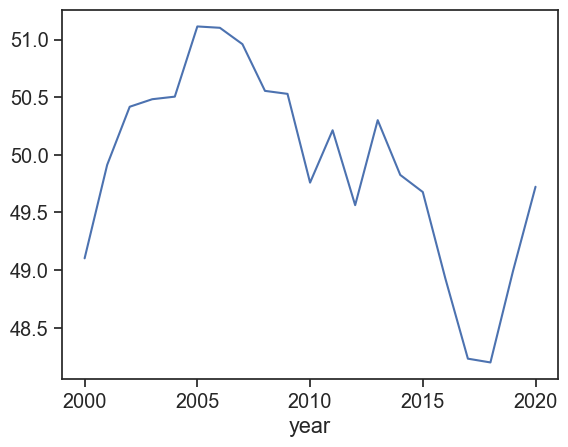

In [11]:
df_area["Settlements"].plot()

KeyError: 'forests_mangroves'

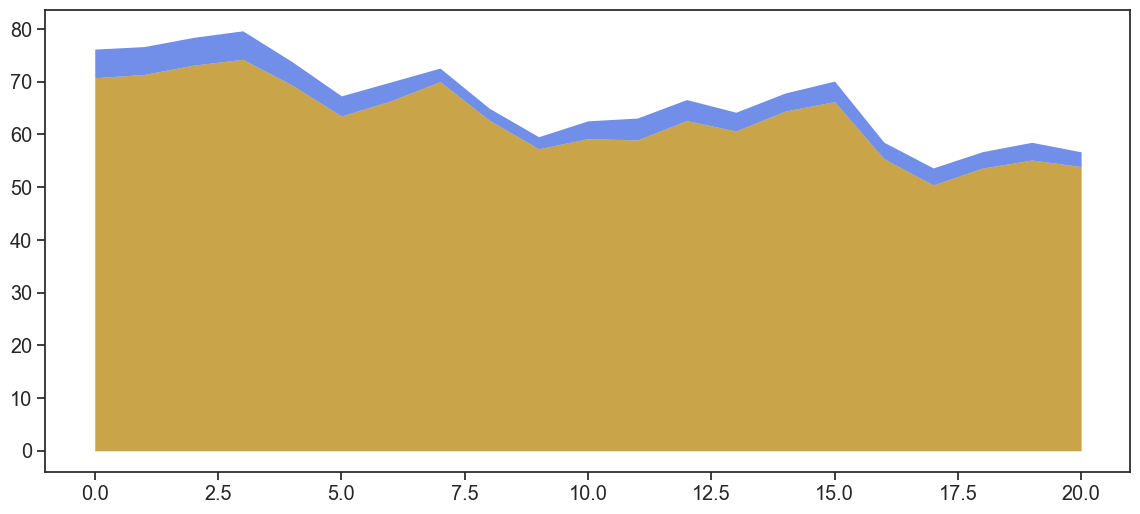

In [8]:
sns.set_theme(style="ticks", font_scale=1.3)

fig, ax = plt.subplots(figsize=(14, 6))
df_area[masked_cols].plot.area(ax=ax, color=COLUMN_COLOR_MAP, alpha=0.75, lw=0)
ax.legend(bbox_to_anchor=(1, 0.5))

ax.set_xlim(0, 20)
ax.set_ylim(0, df_area.sum(axis=1).max() * 0.97)

if LANGUAGE == "en":
    ax.set_ylabel("Area (km²)")
elif LANGUAGE == "es":
    ax.set_ylabel("Área (km²)")
else:
    raise ValueError("Language not supported")

ax.set_xlabel(None)

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

if LANGUAGE == "en":
    ax.set_title("Area by land use class")
elif LANGUAGE == "es":
    ax.set_title("Área por clase de uso de suelo")
else:
    raise ValueError("Language not supported")

fig.savefig(figure_path / "area.jpg", bbox_inches="tight", dpi=200)

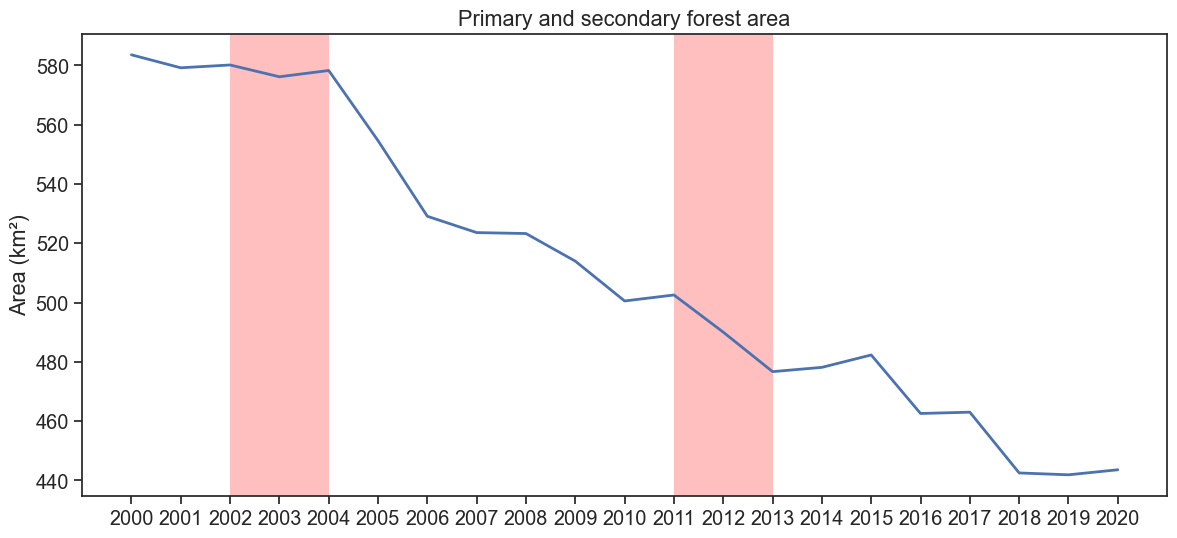

In [9]:
sns.set_theme(style="ticks", font_scale=1.3)

if LANGUAGE == "en":
    wanted_cols = ["Primary forests", "Secondary forests"]
elif LANGUAGE == "es":
    wanted_cols = ["Bosques primarios", "Bosques secundarios"]
else:
    raise ValueError("Language not supported")

df_temp = (
    df_area.filter(wanted_cols, axis=1)
    .filter([str(year) for year in range(2000, 2021)], axis=0)
    .sum(axis=1)
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(df_temp, ax=ax, lw=2, c="C0")
ax.axvspan("2002", "2004", color="red", alpha=0.25, ec="none")
ax.axvspan("2011", "2013", color="red", alpha=0.25, ec="none")

if LANGUAGE == "en":
    ax.set_ylabel("Area (km²)")
    ax.set_title("Primary and secondary forest area")
elif LANGUAGE == "es":
    ax.set_ylabel("Área (km²)")
    ax.set_title("Área de bosques primarios y secundarios")
else:
    raise ValueError("Language not supported")

fig.savefig(figure_path / "area_forest.jpg", bbox_inches="tight", dpi=200)

# Area transitions

## Circle

c:\Users\lain\Documents\AFOLU\.venv\Lib\site-packages\mpl_chord_diagram\utilities.py:167: RuntimeWarning: invalid value encountered in divide
  return (mat[i, :] / x[i]) * (end - start)


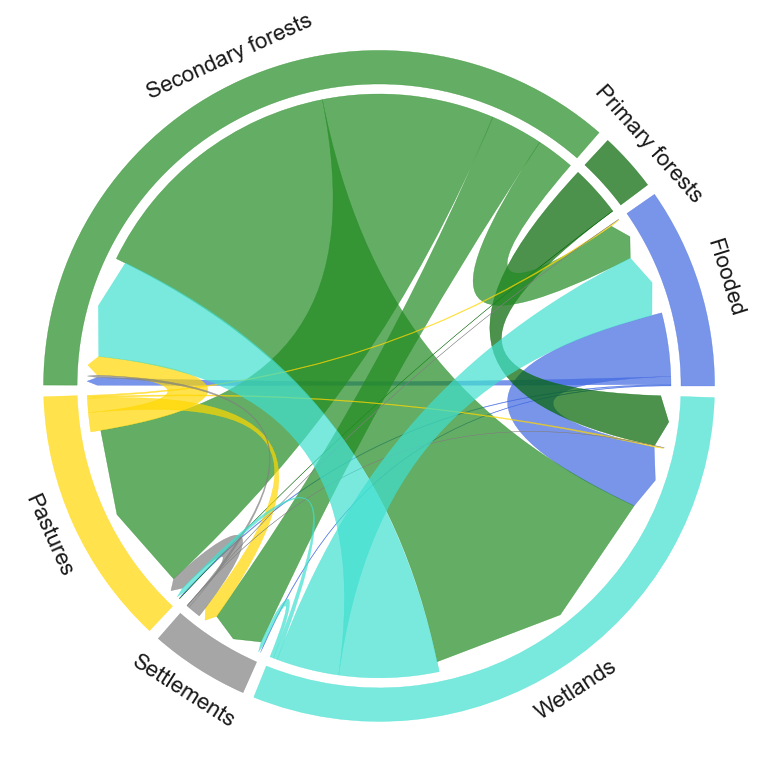

In [10]:
pivot = (
    pd.read_csv(
        out_path
        / "small"
        / "transition"
        / "table_fixed_extra"
        / "2000_2020"
        / f"{ZONE}.csv"
    )
    .set_index("start")
    .sort_index(axis=0)
    .sort_index(axis=1)
)

mask = (pivot.sum(axis=0) > 10 * 1e6) & (pivot.sum(axis=1) > 10 * 1e6)
wanted_idx = mask[mask].index

pivot = pivot.filter(wanted_idx, axis=0).filter(wanted_idx, axis=1)

names = [COLUMN_NAME_MAP[c] for c in pivot.index]

mat = pivot.to_numpy()
np.fill_diagonal(mat, 0)

if ZONE == "MEX+Monterrey":
    rotate_names = [False, False, False, True, True, True, False, False]
elif ZONE == "PER+Maynas":
    rotate_names = [True, False, False, True, True, True, False]
else:
    rotate_names = [False] * len(names)

fig, ax = plt.subplots(figsize=(8, 8))
diag = chord_diagram(
    mat,
    ax=ax,
    names=names,
    directed=True,
    rotate_names=rotate_names,
    colors=[COLUMN_COLOR_MAP[c] for c in names],
    fontsize=16,
)
fig.savefig(figure_path / "chord_bidirectional.jpg", bbox_inches="tight", dpi=200)

# Emissions

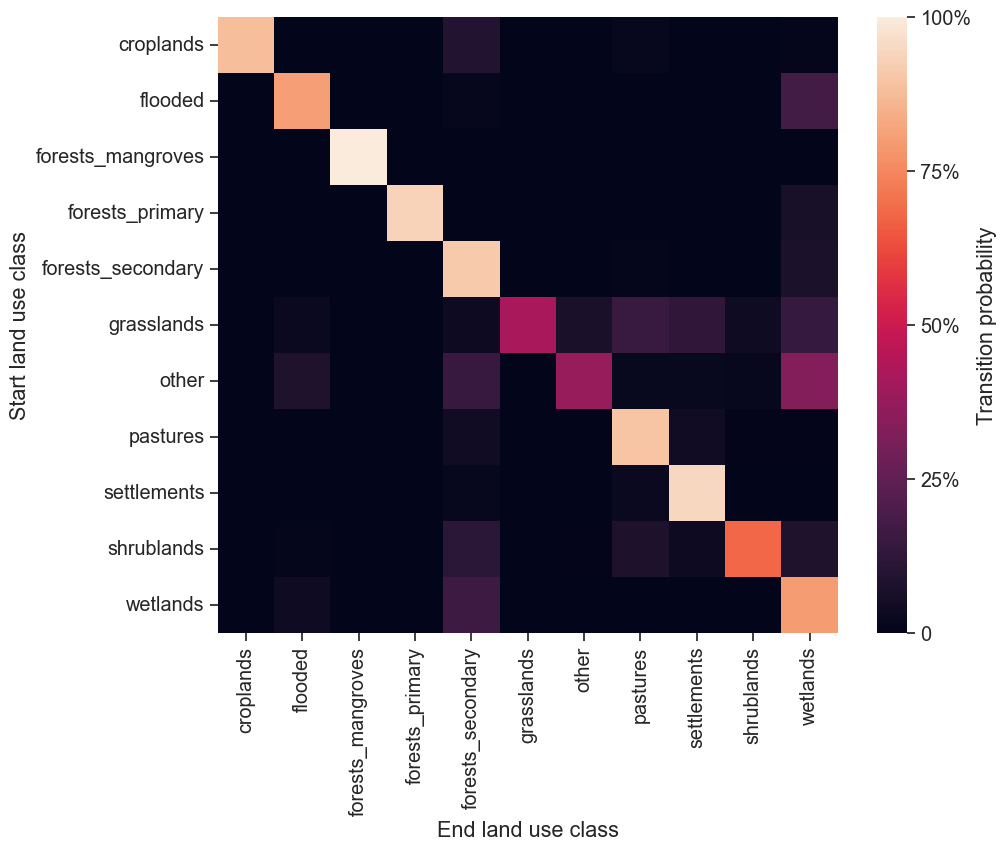

In [11]:
df_cube = (
    pd.read_csv(out_path / "small" / "transition" / "cube" / f"{ZONE}.csv")
    .melt(id_vars="time_period")
    .assign(
        start=lambda df: df["variable"]
        .str.split("_to_")
        .str[0]
        .str.replace("pij_lndu_", ""),
        end=lambda df: df["variable"].str.split("_to_").str[1],
    )
    .drop(columns=["variable"])
    .pivot_table(index="start", columns="end", values="value")
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_cube, ax=ax)
ax.set_xlabel("End land use class")
ax.set_ylabel("Start land use class")
cbar = ax.collections[0].colorbar
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])
cbar.set_ticklabels(["0", "25%", "50%", "75%", "100%"])
cbar.set_label("Transition probability")

fig.savefig(figure_path / "transition_heatmap.jpg", bbox_inches="tight", dpi=200)

In [21]:
df_out = pd.read_csv(out_path / "small" / "emissions" / f"{ZONE}.csv").query(
    "time_period < 21"
)

In [24]:
df_out[[c for c in df_out.columns if "sequestration" in c]]

,emission_co2e_co2_lndu_biomass_sequestration_grasslands,emission_co2e_co2_lndu_biomass_sequestration_other,emission_co2e_co2_lndu_biomass_sequestration_pastures,emission_co2e_co2_lndu_biomass_sequestration_settlements,emission_co2e_co2_lndu_biomass_sequestration_shrublands,emission_co2e_co2_lndu_biomass_sequestration_wetlands,emission_co2e_co2_frst_sequestration_mangroves,emission_co2e_co2_frst_sequestration_primary,emission_co2e_co2_frst_sequestration_secondary
0,-0.0,-0.0,-0.0,-0.0,-0.000155,-0.0,-0.0,-0.007246,-0.092389
1,-0.0,-0.0,-0.0,-0.0,-0.000156,-0.0,-0.0,-0.007246,-0.092797
2,-0.0,-0.0,-0.0,-0.0,-0.000144,-0.0,-0.0,-0.007246,-0.093264
3,-0.0,-0.0,-0.0,-0.0,-0.000144,-0.0,-0.0,-0.007246,-0.093532
4,-0.0,-0.0,-0.0,-0.0,-0.000229,-0.0,-0.0,-0.007245,-0.094125
5,-0.0,-0.0,-0.0,-0.0,-0.000246,-0.0,-0.0,-0.007246,-0.090178
6,-0.0,-0.0,-0.0,-0.0,-0.000199,-0.0,-0.0,-0.007246,-0.085954
7,-0.0,-0.0,-0.0,-0.0,-0.000194,-0.0,-0.0,-0.007246,-0.084767
8,-0.0,-0.0,-0.0,-0.0,-0.000271,-0.0,-0.0,-0.007246,-0.084944
9,-0.0,-0.0,-0.0,-0.0,-0.000305,-0.0,-0.0,-0.007246,-0.083427


In [31]:
(
    df_out["emission_co2e_co2_frst_sequestration_primary"]
    + df_out["emission_co2e_co2_frst_sequestration_secondary"]
    + df_out["emission_co2e_ch4_frst_methane_primary"]
    + df_out["emission_co2e_ch4_frst_methane_secondary"]
    + df_out["emission_co2e_co2_frst_forest_fires"]
)

0    -0.097998
1    -0.098400
2    -0.098859
3    -0.099123
4    -0.099707
5    -0.095820
6    -0.091661
7    -0.090493
8    -0.090666
9    -0.089173
10   -0.086967
11   -0.087348
12   -0.085167
13   -0.082906
14   -0.083110
15   -0.084076
16   -0.080533
17   -0.080723
18   -0.076912
19   -0.076741
20   -0.077029
dtype: float64

In [26]:
df_out["emission_co2e_subsector_total_frst"]

0    -0.097998
1    -0.098400
2    -0.098859
3    -0.099123
4    -0.099707
5    -0.095820
6    -0.091661
7    -0.090493
8    -0.090666
9    -0.089173
10   -0.086967
11   -0.087348
12   -0.085167
13   -0.082906
14   -0.083110
15   -0.084076
16   -0.080533
17   -0.080723
18   -0.076912
19   -0.076741
20   -0.077029
Name: emission_co2e_subsector_total_frst, dtype: float64

In [13]:
wanted_cols = [
    "emission_co2e_subsector_total_frst",
    "emission_co2e_subsector_total_lndu",
    "emission_co2e_co2_soil_soc_mineral_soils",
    "emission_co2e_n2o_soil_mineral_soils",
    "emission_co2e_n2o_soil_organic_soils",
    "time_period",
]

if LANGUAGE == "en":
    name_map = {
        "emission_co2e_subsector_total_frst": "Forests",
        "emission_co2e_subsector_total_lndu": "Land use transitions",
        "emission_co2e_co2_soil_soc_mineral_soils": "Soil mineralization",
        "emission_co2e_n2o_soil_mineral_soils": "Soil mineralization (N2O equiv.)",
        "emission_co2e_n2o_soil_organic_soils": "Organic soil (N2O equiv.)",
    }
elif LANGUAGE == "es":
    name_map = {
        "emission_co2e_subsector_total_frst": "Bosques",
        "emission_co2e_subsector_total_lndu": "Transiciones de uso de suelo",
        "emission_co2e_co2_soil_soc_mineral_soils": "Mineralización del suelo",
        "emission_co2e_n2o_soil_mineral_soils": "Mineralización del suelo\n(equivalente N2O)",
        "emission_co2e_n2o_soil_organic_soils": "Suelo orgánico\n(equivalente N2O)",
    }
else:
    raise ValueError("Language not supported")

df_plot = (
    df_out[wanted_cols]
    .rename(columns=name_map)
    .assign(time_period=lambda df: (df["time_period"] + 2000))
    .set_index("time_period")
)

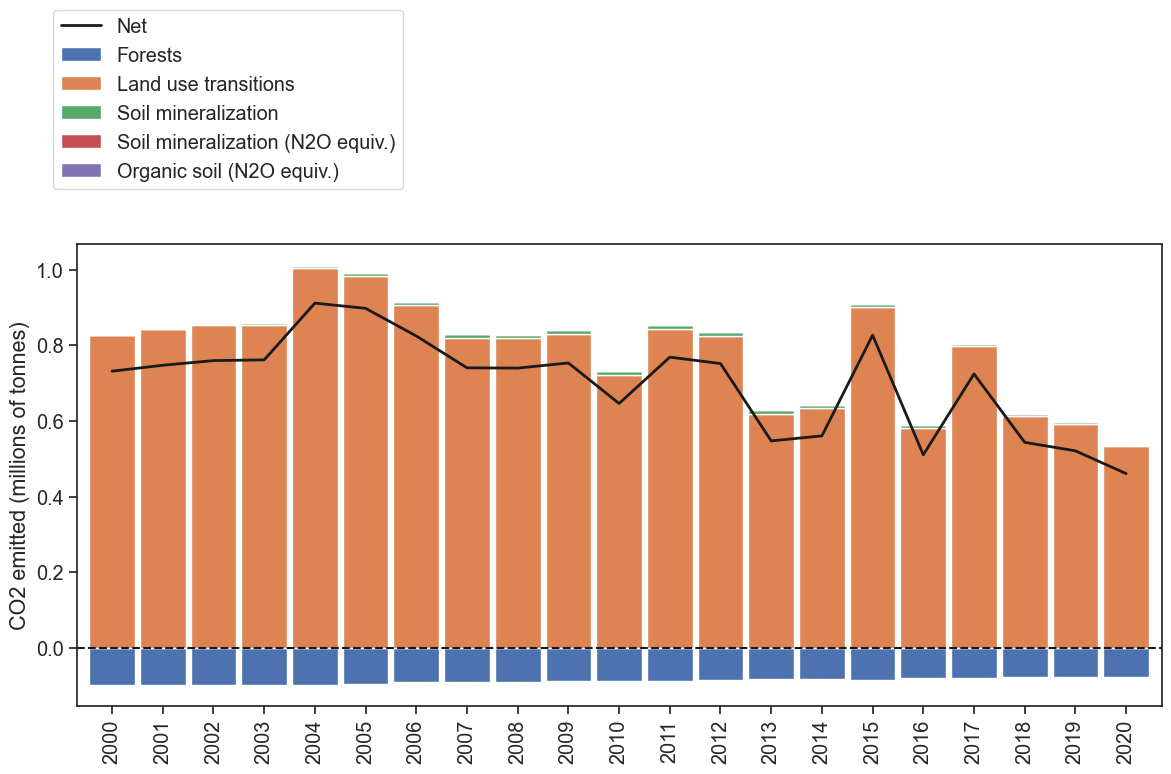

In [14]:
sns.set_theme(style="ticks", font_scale=1.3)

fig, ax = plt.subplots(figsize=(14, 6))
df_plot.plot.bar(stacked=True, ax=ax, width=0.9, legend=False)

if LANGUAGE == "en":
    label = "Net"
elif LANGUAGE == "es":
    label = "Neto"
else:
    raise ValueError("Language not supported")

df_plot.sum(axis=1).reset_index().assign(
    time_period=lambda df: df["time_period"].astype(str)
).set_index("time_period")[0].plot(ax=ax, c="k", label=label, lw=2)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.axhline(0, 0, 1, c="k", ls="--")

ax.set_xlabel(None)

if LANGUAGE == "en":
    ax.set_ylabel("CO2 emitted (millions of tonnes)")
elif LANGUAGE == "es":
    ax.set_ylabel("CO2 emitido (millones de toneladas)")
else:
    raise ValueError("Language not supported")

ax.legend(bbox_to_anchor=(0.31, 1.53))
fig.savefig(figure_path / "carbon.jpg", bbox_inches="tight", dpi=200)

# Emissions by transition

In [15]:
def prettify_column(c: str, pretty_labels: bool) -> str:
    if c == "year":
        return c

    c = c.replace("emission_co2e_co2_lndu_conversion_", "")
    start, end = c.split("_to_")
    if pretty_labels:
        return f"{COLUMN_NAME_MAP[start]}-{COLUMN_NAME_MAP[end]}"
    else:
        return f"{start}-{end}"

In [16]:
df_transitions = (
    pd.read_csv(out_path / "small" / "transitions_emissions" / f"{ZONE}.csv")
    .drop(columns=["Unnamed: 0"])
    .assign(year=range(2000, 2036))
    .query("2000 <= year <= 2020")
    .assign(year=lambda df: df["year"].astype(str))
    .set_index("year")
)
df_transitions.columns = [
    prettify_column(c, pretty_labels=True) for c in df_transitions.columns
]

In [20]:
pd.read_csv(out_path / "small" / "transitions_emissions" / f"{ZONE}.csv")[
    "emission_co2e_co2_lndu_conversion_pastures_to_croplands"
]

0     2.729553e-06
1     1.925191e-06
2     2.244111e-06
3     2.409590e-06
4     1.288827e-06
5     8.077430e-07
6     1.778070e-06
7     4.527230e-06
8     7.605738e-06
9     8.582003e-06
10    9.398426e-06
11    6.480096e-06
12    1.946204e-05
13    1.055260e-05
14    2.614067e-05
15    1.511234e-05
16    8.115584e-06
17    6.661692e-06
18    1.915822e-05
19    2.119553e-05
20    1.049473e-04
21    1.720307e-05
22    1.729747e-05
23    1.740197e-05
24    1.751036e-05
25    1.761896e-05
26    1.772561e-05
27    1.782908e-05
28    1.792873e-05
29    1.802422e-05
30    1.811544e-05
31    1.820243e-05
32    1.828528e-05
33    1.836412e-05
34    1.843913e-05
35    1.851050e-05
Name: emission_co2e_co2_lndu_conversion_pastures_to_croplands, dtype: float64

15314.791473497336


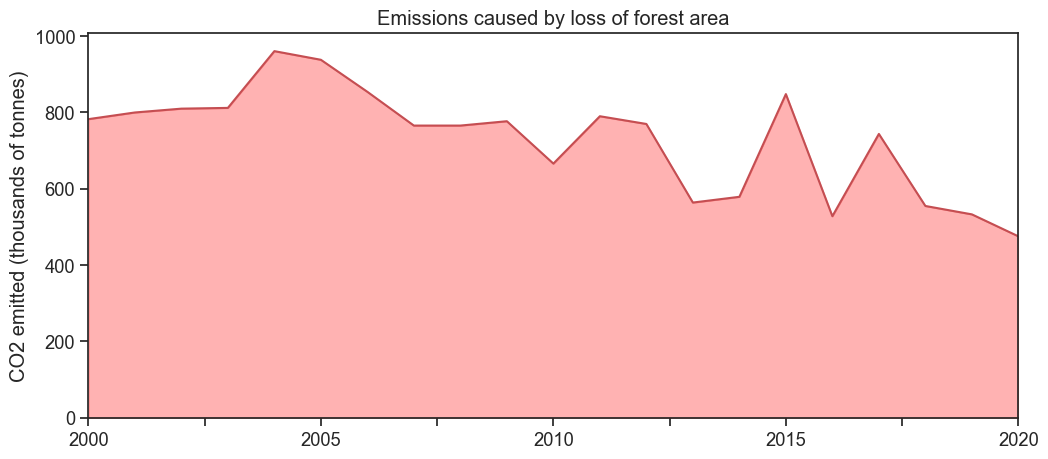

In [18]:
sns.set_theme(font_scale=1.2, style="ticks")

if LANGUAGE == "en":
    df_temp = (
        df_transitions[[c for c in df_transitions.columns if "forests" in c.casefold()]]
        .sum(axis=1)
        .multiply(1000)
    )
elif LANGUAGE == "es":
    df_temp = (
        df_transitions[[c for c in df_transitions.columns if c.startswith("Bosques")]]
        .sum(axis=1)
        .multiply(1000)
    )
else:
    raise ValueError("Language not supported")

fig, ax = plt.subplots(figsize=(12, 5))
df_temp.plot(ax=ax, c="r")
print(df_temp.sum())

if LANGUAGE == "en":
    ax.set_title("Emissions caused by loss of forest area")
    ax.set_ylabel("CO2 emitted (thousands of tonnes)")
elif LANGUAGE == "es":
    ax.set_title("Emisiones causadas por la pérdida de área forestal")
    ax.set_ylabel("CO2 emitido (miles de toneladas)")
else:
    raise ValueError("Language not supported")

ax.set_xlabel(None)
ax.fill_between(df_temp.index, df_temp, alpha=0.3, color="red")

ax.set_xlim("2000", "2020")
ax.set_ylim(0, ax.get_ylim()[1])

fig.savefig(figure_path / "emissions_from_forest.jpg", bbox_inches="tight", dpi=200)

In [19]:
df_temp = (
    df_transitions.reset_index()
    .melt(id_vars="year")
    .assign(
        start=lambda df: df["variable"].str.split("-").str[0],
        end=lambda df: df["variable"].str.split("-").str[1],
    )
    .drop(columns="variable")
    .groupby(["year", "end"])["value"]
    .sum()
    .reset_index()
    .pivot_table(index="year", columns="end", values="value")
)

if LANGUAGE == "en":
    df_temp = df_temp.filter(["Croplands", "Pastures", "Settlements"])
elif LANGUAGE == "es":
    df_temp = df_temp.filter(["Cultivos", "Pastizales p/ganado", "Asentamientos"])
else:
    raise ValueError("Language not supported")

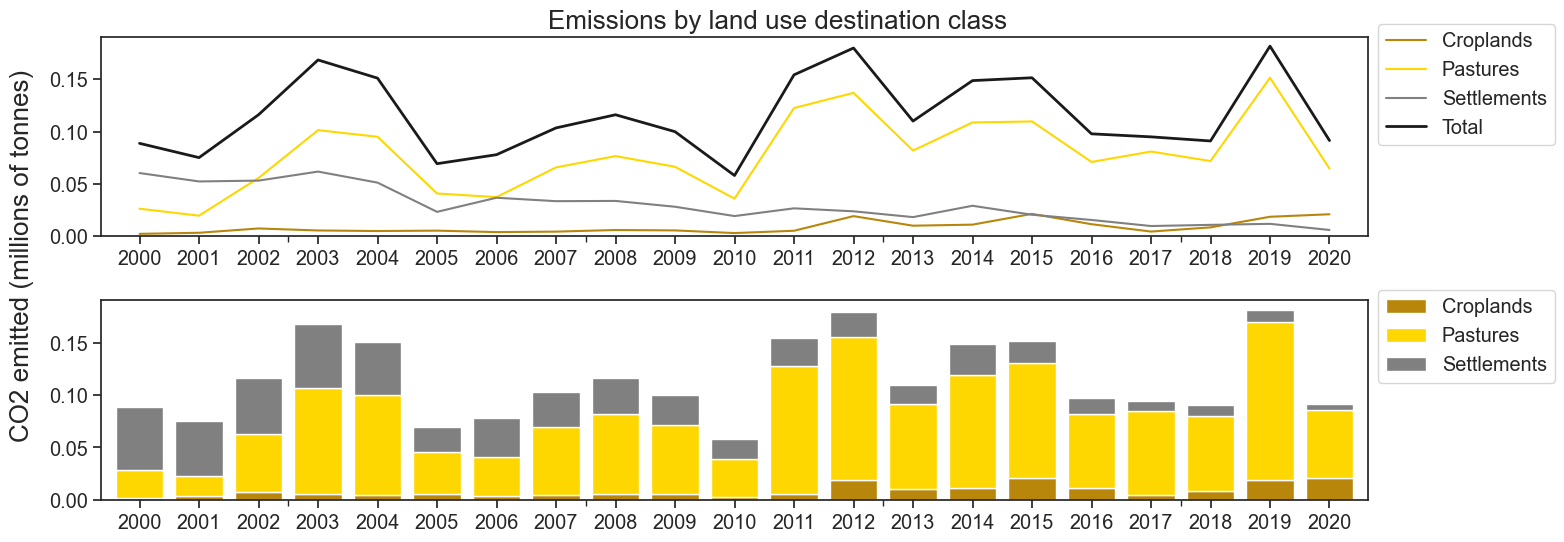

In [21]:
sns.set_theme(font_scale=1.3, style="ticks")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

df_temp.plot(ax=ax1, legend=True, color=COLUMN_COLOR_MAP)
df_temp.sum(axis=1).plot(ax=ax1, c="k", lw="2", label="Total")

df_temp.plot.bar(ax=ax2, stacked=True, width=0.8, rot=0, color=COLUMN_COLOR_MAP)

ax1.set_ylim(*ax2.get_ylim())
ax1.set_xlabel(None)
ax1.xaxis.set_tick_params(labelbottom=True)
ax1.legend(bbox_to_anchor=(1, 0.76), loc="center left")

ax2.set_xlabel(None)
ax2.legend(bbox_to_anchor=(1, 0.82), loc="center left")

if LANGUAGE == "en":
    fig.supylabel("CO2 emitted (millions of tonnes)")
    fig.suptitle("Emissions by land use destination class", y=0.91)
elif LANGUAGE == "es":
    fig.supylabel("CO2 emitido (millones de toneladas)")
    fig.suptitle("Emisiones por clase de destino de uso de suelo", y=0.94)
else:
    raise ValueError("Language not supported")

fig.tight_layout()
fig.savefig(figure_path / "emissions_by_end.jpg", bbox_inches="tight", dpi=200)

2.4239895903909323


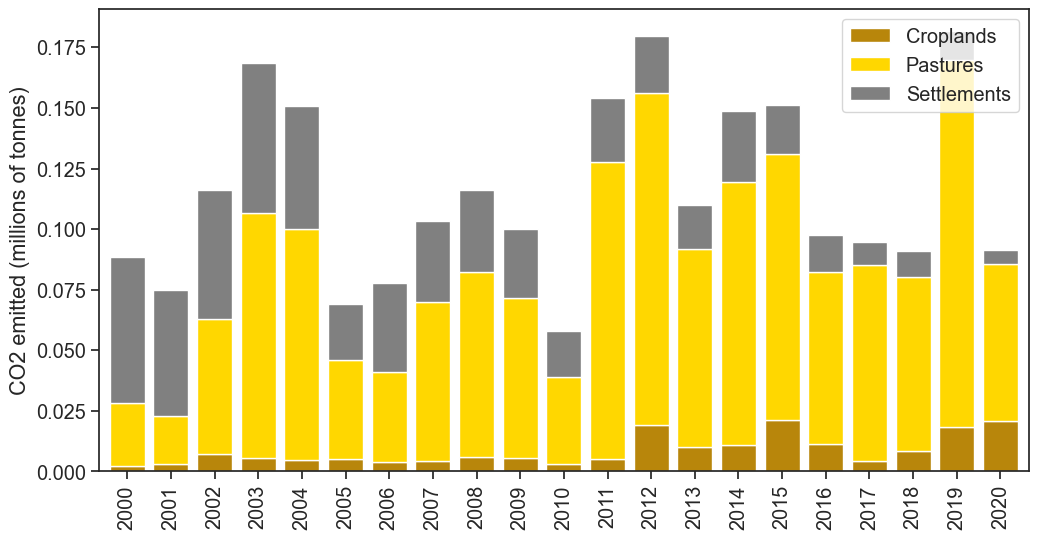

In [23]:
sns.set_theme(font_scale=1.3, style="ticks")

fig, ax = plt.subplots(figsize=(12, 6))
df_temp.plot.bar(ax=ax, stacked=True, width=0.8, rot=0, color=COLUMN_COLOR_MAP)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_xlabel(None)

print(df_temp.sum().sum())

if LANGUAGE == "en":
    ax.set_ylabel("CO2 emitted (millions of tonnes)")
elif LANGUAGE == "es":
    ax.set_ylabel("CO2 emitido (millones de toneladas)")
else:
    raise ValueError("Language not supported")

In [36]:
df_transitions

,Secondary forests-Croplands,Secondary forests-Flooded,Secondary forests-Grasslands,Secondary forests-Other,Secondary forests-Pastures,Secondary forests-Settlements,Secondary forests-Shrublands,Secondary forests-Wetlands,Pastures-Croplands,Pastures-Settlements,Shrublands-Flooded,Shrublands-Other,Shrublands-Pastures,Shrublands-Settlements,Shrublands-Wetlands,Wetlands-Flooded,Wetlands-Other
year,,,,,,,,,,,,,,,,,
2000,0.002188,0.017820,0.000000,0.002628,0.025843,0.059643,0.002069,0.672123,2.729553e-06,0.000411,0.000004,0.000014,0.000353,0.000250,0.000512,0.001373,0.000066
2001,0.003212,0.008720,0.000012,0.002154,0.019325,0.051695,0.002168,0.712499,1.925191e-06,0.000328,0.000000,0.000036,0.000242,0.000246,0.000429,0.001029,0.000063
2002,0.007340,0.020960,0.000000,0.003612,0.055355,0.052493,0.002730,0.667333,2.244111e-06,0.000296,0.000029,0.000025,0.000252,0.000274,0.000654,0.001229,0.000078
2003,0.005418,0.011522,0.000080,0.004771,0.100777,0.061165,0.009959,0.618098,2.409590e-06,0.000309,0.000014,0.000058,0.000492,0.000220,0.000425,0.001220,0.000085
2004,0.004883,0.010901,0.000000,0.006348,0.093886,0.050508,0.012342,0.781590,1.288827e-06,0.000295,0.000036,0.000089,0.001098,0.000332,0.001887,0.000912,0.000052
2005,0.005252,0.008420,0.000000,0.004209,0.040152,0.022478,0.004436,0.852883,8.077430e-07,0.000246,0.000212,0.000169,0.000610,0.000499,0.001306,0.000739,0.000066
2006,0.003866,0.017628,0.000000,0.003985,0.036835,0.036092,0.003738,0.751772,1.778070e-06,0.000266,0.000054,0.000068,0.000452,0.000333,0.001175,0.001191,0.000072
2007,0.004315,0.018204,0.000058,0.001791,0.065260,0.032600,0.012635,0.630608,4.527230e-06,0.000269,0.000039,0.000047,0.000429,0.000553,0.000573,0.002068,0.000074
2008,0.005853,0.023386,0.000000,0.002284,0.074770,0.032737,0.012636,0.613823,7.605738e-06,0.000262,0.000155,0.000047,0.001733,0.000649,0.000637,0.001767,0.000065


In [48]:
df_temp = (
    df_transitions.reset_index()
    .melt(id_vars="year")
    .assign(
        start=lambda df: df["variable"].str.split("-").str[0],
        end=lambda df: df["variable"].str.split("-").str[1],
    )
    .drop(columns="variable")
    .groupby(["year", "end"])["value"]
    .sum()
    .reset_index()
    .pivot_table(index="year", columns="end", values="value")
    .multiply(1000)
)

# if LANGUAGE == "en":
#     df_temp = df_temp.filter(["Settlements"])
# elif LANGUAGE == "es":
#     df_temp = df_temp.filter(["Asentamientos"])
# else:
#     raise ValueError("Language not supported")

<Axes: xlabel='year'>

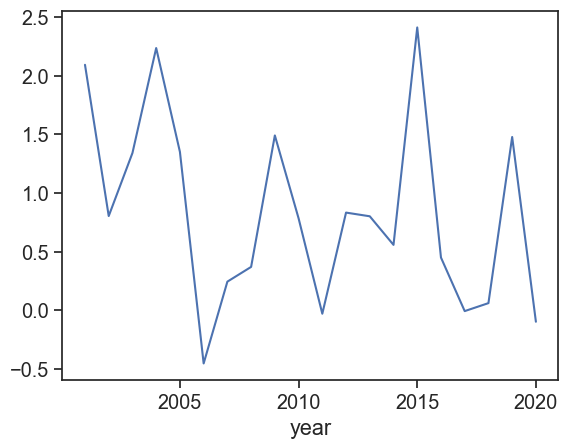

In [52]:
(df_area["Settlements"] - df_area["Settlements"].shift(1)).plot()

<Axes: xlabel='year'>

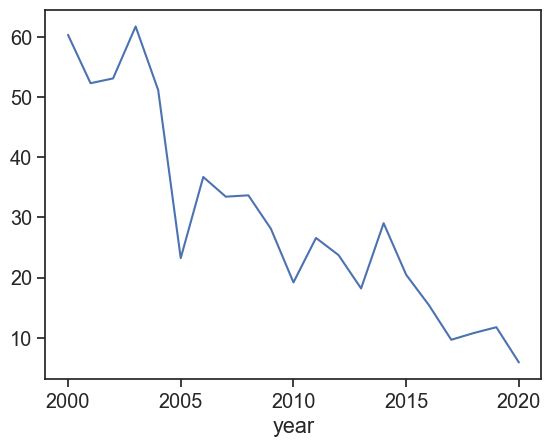

In [47]:
df_temp["Settlements"].plot()

In [40]:
df_temp

,Settlements
year,
2000,60.303309
2001,52.269431
2002,53.063296
2003,61.693968
2004,51.134749
2005,23.222273
2006,36.691129
2007,33.421832
2008,33.648559


624.2326912675512


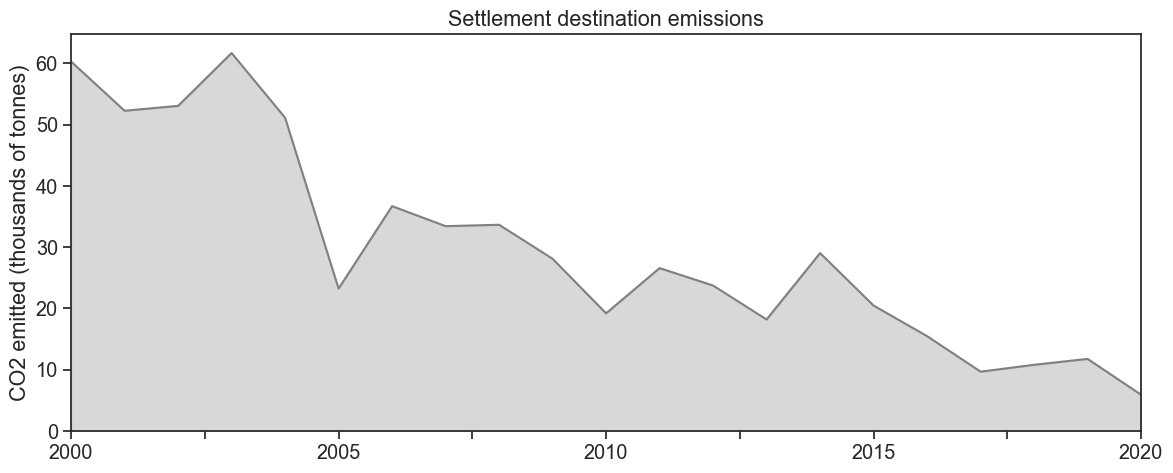

In [27]:
sns.set_theme(font_scale=1.3, style="ticks")

fig, ax = plt.subplots(figsize=(12, 5), sharex=True)

df_temp.plot(ax=ax, legend=False, color=COLUMN_COLOR_MAP)
print(df_temp.sum().item())

if LANGUAGE == "en":
    ax.fill_between(
        df_temp.index,
        df_temp.values.flatten(),
        alpha=0.3,
        color=COLUMN_COLOR_MAP["Settlements"],
    )
    ax.set_ylabel("CO2 emitted (thousands of tonnes)")
    ax.set_title("Settlement destination emissions")
elif LANGUAGE == "es":
    ax.fill_between(
        df_temp.index,
        df_temp.values.flatten(),
        alpha=0.3,
        color=COLUMN_COLOR_MAP["Asentamientos"],
    )
    ax.set_ylabel("CO2 emitido (miles de toneladas)")
    ax.set_title("Emisiones producidas por urbanización")
else:
    raise ValueError("Language not supported")

ax.set_xlabel(None)

ax.set_xlim("2000", "2020")
ax.set_ylim(0, ax.get_ylim()[1])

fig.tight_layout()
fig.savefig(figure_path / "emissions_by_urb.jpg", bbox_inches="tight", dpi=200)

In [32]:
corr = pd.concat(
    [df_area["Settlements"].rename("area"), df_temp["Settlements"].rename("emissions")],
    axis=1,
)

<Axes: xlabel='area', ylabel='emissions'>

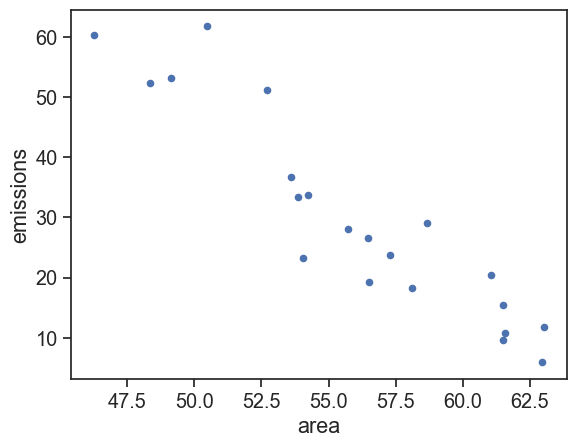

In [35]:
corr.plot.scatter(x="area", y="emissions")